In [17]:
%%capture
!pip install mlxtend

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print("Импорт успешен!")

Импорт успешен!


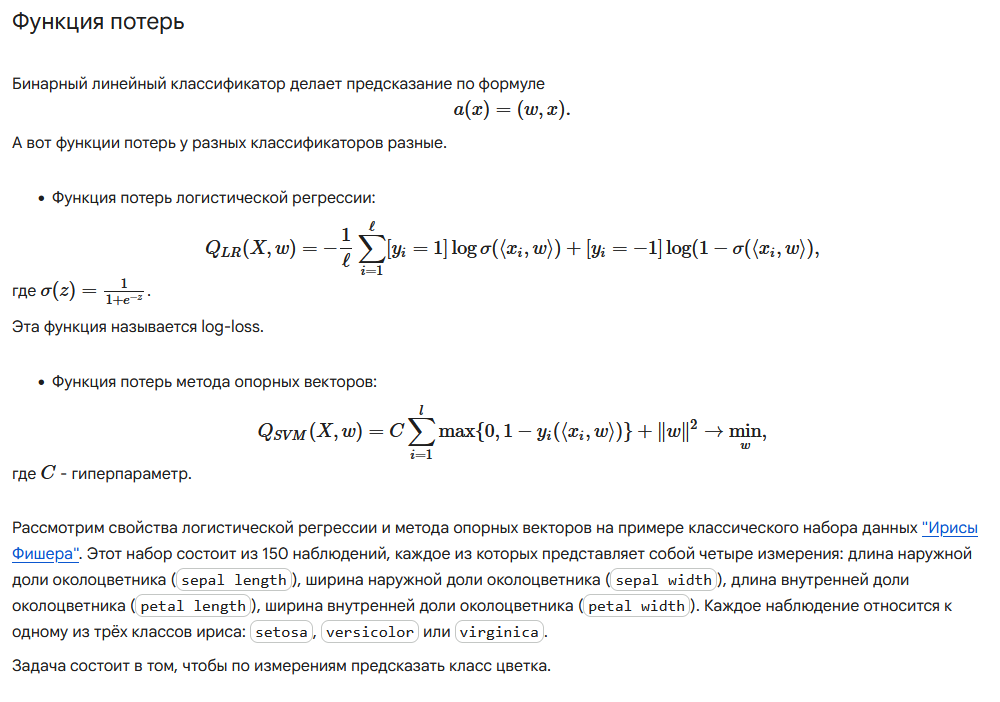

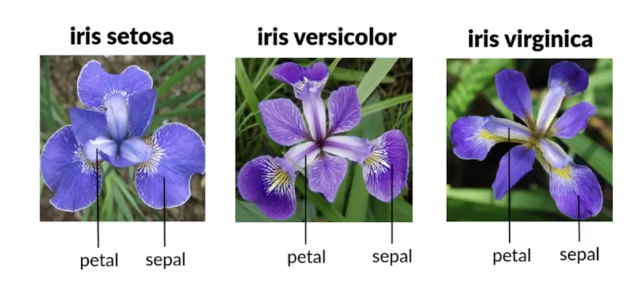

In [4]:
from sklearn.datasets import load_iris
data = load_iris()
X = pd.DataFrame(data['data'], columns = data['feature_names'])
y = data['target']

In [5]:
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [10]:
set(y)

{np.int64(0), np.int64(1), np.int64(2)}

In [13]:
# Сделаем всего 2 класса ирисов: 1 и (не 1 = 0)
y[y != 1] = 0
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

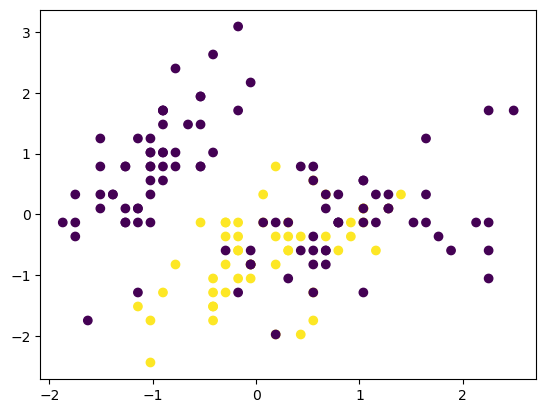

In [14]:
# Оставим 2 признака: sepal length (cm) и sepal width (cm)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
np.random.seed(123)

X = X[['sepal length (cm)', 'sepal width (cm)']]

ss = StandardScaler()
X = ss.fit_transform(X)

plt.scatter(X[:, 0], X[:, 1], c = y)

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

lr = LogisticRegression()
lr.fit(X, y)
predLR = lr.predict(X)

svm = LinearSVC()
svm.fit(X, y)
predSVM = svm.predict(X)

print(f'Logistic regression coefficients: {lr.coef_}')
print(f'Support vector machine coefficients: {svm.coef_}')

Logistic regression coefficients: [[ 0.1033129  -1.29975427]]
Support vector machine coefficients: [[ 0.02577291 -0.52074853]]


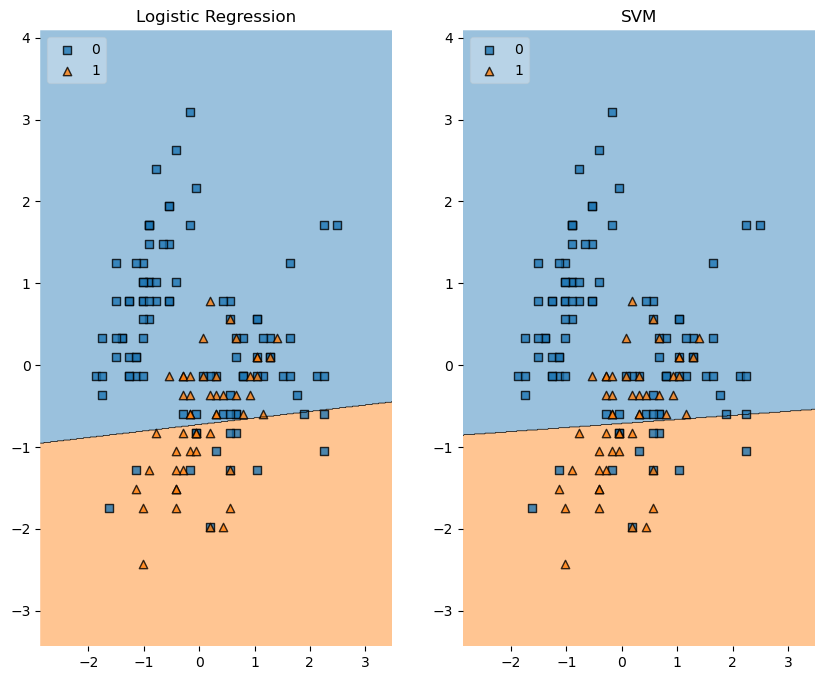

In [22]:
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions
import matplotlib.gridspec as gridspec
import itertools
gs = gridspec.GridSpec(1, 2)

fig = plt.figure(figsize = (10, 8))

labels = ['Logistic Regression', 'SVM']
for clf, lab, grd in zip([lr, svm]
                         , labels
                         , itertools.product([0, 1], repeat = 2)):
    ax = plt.subplot(gs[grd[0], grd[1]])
    fig = plot_decision_regions(X = X, y = np.array(y), clf = clf, legend = 2)
    plt.title(lab)

plt.show()

In [24]:
from sklearn.metrics import r2_score


print(f'LR r2_score is {r2_score(y, predLR)}')
print(f'SVM r2_score is {r2_score(y, predSVM)}')

LR r2_score is -0.2899999999999998
SVM r2_score is -0.22999999999999998


# Обучим логистическую регрессию для предсказания того, откликнется клиент на рекламное предложение (target = 1) или нет (target = 0).

In [157]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

In [158]:
data = pd.read_csv('https://raw.githubusercontent.com/evgpat/edu_stepik_practical_ml/main/datasets/clients_data.csv')

In [159]:
data.head()

,AGE,SOCSTATUS_WORK_FL,SOCSTATUS_PENS_FL,GENDER,CHILD_TOTAL,DEPENDANTS,PERSONAL_INCOME,LOAN_NUM_TOTAL,LOAN_NUM_CLOSED,LOAN_DLQ_NUM,TARGET
0,49,1,0,1,2,1,5000.0,1,1,2,0
1,32,1,0,1,3,3,12000.0,1,1,1,0
2,52,1,0,1,4,0,9000.0,2,1,0,0
3,39,1,0,1,1,1,25000.0,1,1,3,0
4,30,1,0,0,0,0,12000.0,2,1,2,0


In [160]:
from sklearn.model_selection import train_test_split

X = data.drop('TARGET', axis = 1)
y = data['TARGET']

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, train_size = 0.7, random_state = 123)

In [161]:
# Обучим Логистическую регрессию с параметрами по умолчанию

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

In [162]:
lr.fit(Xtrain, ytrain)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [163]:
predLR = lr.predict(Xtest)

In [164]:
predLR[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [165]:
# Посчитаем долю правильных ответов (accuracy), точность (precision), полноту (recall), ср. гармоничсекое точности и полноты (f1_score)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracyLR = accuracy_score(ytest, predLR)
precisionLR = precision_score(ytest, predLR)
recallLR = recall_score(ytest, predLR)
f1_scoreLR = f1_score(ytest, predLR)
print(f'accuracy is {accuracyLR}\nprecision is {precisionLR}\nrecall is {recallLR}\nf1_score is {f1_scoreLR}')

accuracy is 0.8767243266914824
precision is 0.0
recall is 0.0
f1_score is 0.0


In [166]:
# Предскажем вероятности классов с помощью обученной LogisticRegression на тестовых данных
# Для каждого объекта предсказано 2 вер-ти: 
# 1) веростность того, что объект принадлежит классу 0
# 2) веростность того, что объект принадлежит классу 1

probs_test = lr.predict_proba(Xtest)

probs_test[:10,0]

array([0.93860209, 0.90059543, 0.71082928, 0.78458463, 0.87089508,
       0.95850846, 0.93631926, 0.96561594, 0.94889209, 0.93090805])

In [167]:
# Посмотрим веса модели

lr.coef_, lr.intercept_

(array([[-4.61776592e-02, -1.47060998e-01, -8.61216624e-02,
         -1.54085678e-01,  1.91467444e-01, -1.41695843e-01,
          2.01731554e-05, -6.01016096e-02, -2.31279582e-01,
          2.92927735e-01]]),
 array([-0.24169876]))

In [168]:
# Посчитаем процент объектов, относящихся к положительному классу
100 * y.value_counts()[1]/len(y)

np.float64(11.90304145043684)

In [169]:
# Посчитаем предсказания модели, если порог = 0.1 (если вероятность >= 0.1, то относим объект к положительному классу)
predLR_01 = (probs_test[:, 1] >= 0.1).astype(int)

In [170]:
# Посчитаем долю правильных ответов (accuracy), точность (precision), полноту (recall), ср. гармоничсекое точности и полноты (f1_score) 
# Для модели LR с порогом 0.1

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracyLR = accuracy_score(ytest, predLR_01)
precisionLR = precision_score(ytest, predLR_01)
recallLR = recall_score(ytest, predLR_01)
f1_scoreLR = f1_score(ytest, predLR_01)
print(f'accuracy is {accuracyLR}\nprecision is {precisionLR}\nrecall is {recallLR}\nf1_score is {f1_scoreLR}')

accuracy is 0.495511276549157
precision is 0.15554678247137782
recall is 0.7048300536672629
f1_score is 0.25485122897800777


In [171]:
# Получаем веса (для бинарной классификации это одномерный массив)
weights = lr.coef_.flatten()  # или model.coef_[0], если coef_ имеет форму (1, n_features)

# Если есть имена признаков, создаём Series для удобства
if hasattr(lr, 'feature_names_in_'):
    # Если модель обучалась на DataFrame с именами столбцов
    feature_weights = pd.Series(weights, index=lr.feature_names_in_)
else:
    # Иначе используем список, переданный вручную, или индексы
    feature_names = [f"feature_{i}" for i in range(len(weights))]
    feature_weights = pd.Series(weights, index=feature_names)

# Оставляем только положительные веса
positive_weights = feature_weights[feature_weights > 0]

# Находим наименьший положительный вес
if not positive_weights.empty:
    min_positive_feature = positive_weights.idxmin()  # название признака
    min_positive_value = positive_weights.min()       # значение веса
    print(f"Признак с наименьшим положительным весом: '{min_positive_feature}' = {min_positive_value:.4f}")
else:
    print("Нет признаков с положительными весами.")

Признак с наименьшим положительным весом: 'PERSONAL_INCOME' = 0.0000


Порог, максимизирующий f1: 0.11, значение f1: 0.26277897768178543


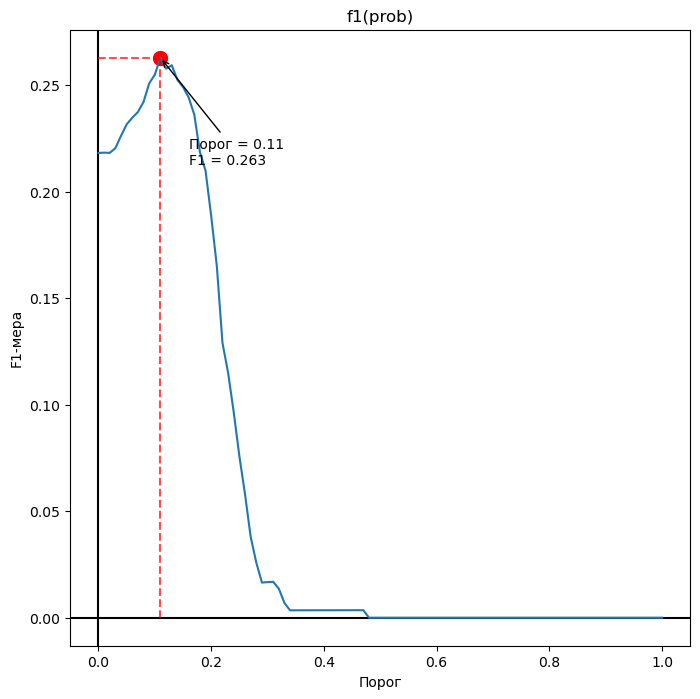

In [172]:
# Подбор оптимального (: f1 -> max) порога для перевода вероятностей в классы
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

prob_list = np.arange(0, 1.01, 0.01)
prob_max = .0
f1_max = .0
f1_list = []

for i in range(len(prob_list)):
    predLR_i = (probs_test[:, 1] >= prob_list[i]).astype(int)
    f1_i = f1_score(ytest, predLR_i)
    #print(prob_list[i], f1_i)
    f1_list.append(f1_i)
    if f1_i > f1_max:
        f1_max = f1_i
        prob_max = prob_list[i]

print(f'Порог, максимизирующий f1: {prob_max}, значение f1: {f1_max}')

# Нарисуем график f1(threshold) и отметим на нем оптимальный порог (максимизирующий)

plt.figure(figsize = (8, 8))

plt.axvline(x = 0, c = 'black') # Добавление оси ординат (ax vertical line)
plt.axhline(y = 0, c = 'black') # Добавление оси aбсцисс (ax vertical line)
plt.title('f1(prob)') # Добавление заголовка
plt.plot(prob_list, f1_list) # Добавление графика
plt.scatter(prob_max, f1_max, color='red', s=100, label='Максимум F1') # Добавление точки, в которой f1 максимальна
plt.annotate(f'Порог = {prob_max:.2f}\nF1 = {f1_max:.3f}', 
             xy=(prob_max, f1_max), 
             xytext=(prob_max+0.05, f1_max-0.05),
             arrowprops=dict(arrowstyle='->')) # Добавление стрелочки с координатами точки
plt.hlines(y=f1_max, xmin=min(prob_list), xmax=prob_max, linestyle='--', color='red', alpha=0.7) # Добавление горизонтальной пунктирной линии
plt.vlines(x=prob_max, ymin=min(f1_list), ymax=f1_max, linestyle='--', color='red', alpha=0.7) # Добавление вертикальной пунктирной линии
plt.xlabel('Порог') # Добавление подписи оси ординат
plt.ylabel('F1-мера') # Добавление подписи оси абсцисс
plt.show()

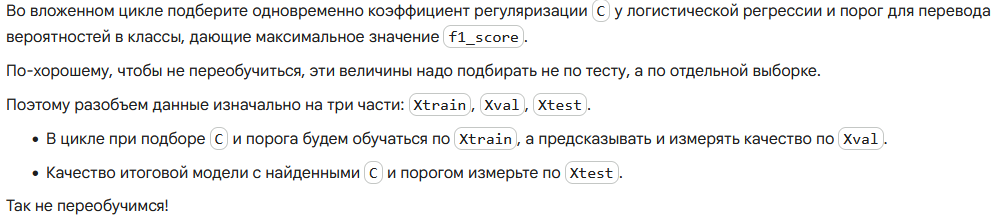

In [173]:
from sklearn.model_selection import train_test_split

Xtrain, Xval, ytrain, yval = train_test_split(Xtrain, ytrain, train_size = 0.7, random_state = 123)

In [189]:
# Подбор оптимального (: f1 -> max) коэффициента регуляризации C и порога для перевода вероятностей в классы - написала сама
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import numpy as np

lr = LogisticRegression()

C_values = np.logspace(-3, 3, 50)

prob_max_grob = .0
f1_max_glob = .0
c_max_glob = .0

for c in C_values:
    lr = LogisticRegression(C = c, max_iter=1000)
    lr.fit(Xtrain, ytrain)

    predLR_val = lr.predict(Xval)
    probs_test = lr.predict_proba(Xval)

    prob_list = np.arange(0, 1.01, 0.01)
    prob_max = .0
    f1_max = .0
    f1_list = []
    
    for i in range(len(prob_list)):
        predLR_i = (probs_test[:, 1] >= prob_list[i]).astype(int)
        f1_i = f1_score(yval, predLR_i)
        #print(prob_list[i], f1_i)
        f1_list.append(f1_i)
        if f1_i > f1_max:
            f1_max = f1_i
            prob_max = prob_list[i]

    if f1_max > f1_max_glob:
        prob_max_grob = prob_max
        f1_max_glob = f1_max
        c_max_glob = c

In [190]:
print(f"Лучший C: {c_max_glob:.4f}, порог: {prob_max_grob:.2f}, F1: {f1_max_glob:.4f}")

Лучший C: 244.2053, порог: 0.15, F1: 0.2590


In [182]:
# Подбор оптимального (: f1 -> max) коэффициента регуляризации C и порога для перевода вероятностей в классы - написал Дипсик
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
import numpy as np
from tqdm import tqdm  # импортируем tqdm

# Значения C (логарифмическая шкала)
C_values = np.logspace(-3, 3, 50)

# Пороги для перебора
thresholds = np.arange(0, 1.01, 0.01)

# Переменные для хранения лучших результатов
best_f1 = 0.0
best_C = None
best_threshold = None

# Внешний цикл с tqdm
for C in tqdm(C_values, desc="Подбор C"): # tqdm рисует прогресс выполнения программы
    # Обучаем модель с текущим C
    model = LogisticRegression(C=C, max_iter=1000)  # увеличим max_iter для надёжности
    model.fit(Xtrain, ytrain)
    
    # Получаем вероятности положительного класса на валидации
    proba_val = model.predict_proba(Xval)[:, 1]
    
    # Внутренний цикл по порогам (можно тоже обернуть в tqdm, но это замедлит вывод)
    for thr in thresholds:
        # Преобразуем вероятности в метки согласно порогу
        y_pred_val = (proba_val >= thr).astype(int)
        
        # Считаем F1
        f1 = f1_score(yval, y_pred_val)
        
        # Если нашли лучшее значение для данного C, запоминаем
        if f1 > best_f1:
            best_f1 = f1
            best_C = C
            best_threshold = thr

print(f"Лучший C: {best_C:.4f}, порог: {best_threshold:.2f}, F1: {best_f1:.4f}")

Подбор C: 100%|████████████████████████████████████████████████████████████████████████| 50/50 [00:30<00:00,  1.65it/s]

Лучший C: 244.2053, порог: 0.15, F1: 0.2590


In [195]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, train_size = 0.7, random_state = 123)

lr_best = LogisticRegression(C = c_max_glob)
lr_best.fit(Xtrain, ytrain)

predLR_best = lr_best.predict(Xtest)
probs_test = lr_best.predict_proba(Xtest)

predLR_best_threshold = (probs_test[:, 1] >= prob_max_grob).astype(int)

f1 = f1_score(ytest, predLR_best_threshold)
f1

0.24928530588907946

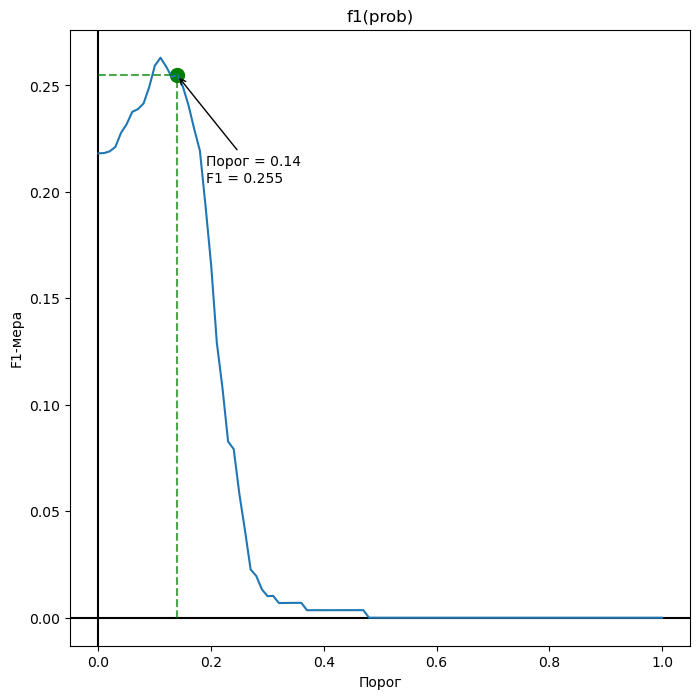

In [197]:
# Нарисуем график f1(threshold) и отметим на нем оптимальный порог (максимизирующий)

prob_list = np.arange(0, 1.01, 0.01)
f1_list = []

for i in range(len(prob_list)):
    predLR_i = (probs_test[:, 1] >= prob_list[i]).astype(int)
    f1_i = f1_score(ytest, predLR_i)
    f1_list.append(f1_i)

plt.figure(figsize = (8, 8))

plt.axvline(x = 0, c = 'black') # Добавление оси ординат (ax vertical line)
plt.axhline(y = 0, c = 'black') # Добавление оси aбсцисс (ax vertical line)
plt.title('f1(prob)') # Добавление заголовка
plt.plot(prob_list, f1_list) # Добавление графика
plt.scatter(prob_max, f1_max, color='green', s=100, label='Максимум F1') # Добавление точки, в которой f1 максимальна
plt.annotate(f'Порог = {prob_max:.2f}\nF1 = {f1_max:.3f}', 
             xy=(prob_max, f1_max), 
             xytext=(prob_max+0.05, f1_max-0.05),
             arrowprops=dict(arrowstyle='->')) # Добавление стрелочки с координатами точки
plt.hlines(y=f1_max, xmin=min(prob_list), xmax=prob_max, linestyle='--', color='green', alpha=0.7) # Добавление горизонтальной пунктирной линии
plt.vlines(x=prob_max, ymin=min(f1_list), ymax=f1_max, linestyle='--', color='green', alpha=0.7) # Добавление вертикальной пунктирной линии
plt.xlabel('Порог') # Добавление подписи оси ординат
plt.ylabel('F1-мера') # Добавление подписи оси абсцисс
plt.show()

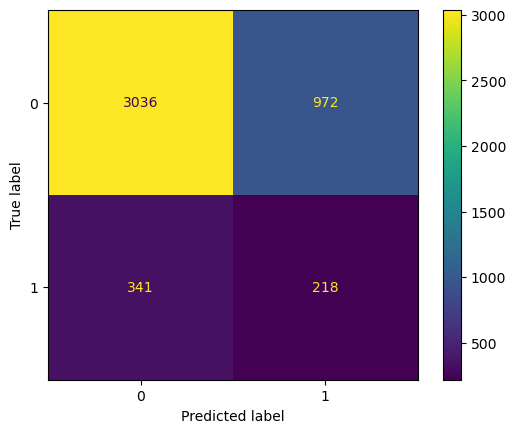

In [198]:
#Посмотрим на матрицу ошибок (confusion matrix)
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(ytest, predLR_best_threshold)
plt.show()

# В этом задании вам предлагается спрогнозировать, купит клиент велосипед или нет, обучив логистическую регрессию

In [199]:
# подключим библиотеки
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

In [200]:
# считаем данные
data = pd.read_csv('https://raw.githubusercontent.com/evgpat/edu_stepik_practical_ml/main/datasets/bike_buyers_clean.csv')

In [201]:
data.head()

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike
0,12496,Married,Female,40000,1,Bachelors,Skilled Manual,Yes,0,0-1 Miles,Europe,42,No
1,24107,Married,Male,30000,3,Partial College,Clerical,Yes,1,0-1 Miles,Europe,43,No
2,14177,Married,Male,80000,5,Partial College,Professional,No,2,2-5 Miles,Europe,60,No
3,24381,Single,Male,70000,0,Bachelors,Professional,Yes,1,5-10 Miles,Pacific,41,Yes
4,25597,Single,Male,30000,0,Bachelors,Clerical,No,0,0-1 Miles,Europe,36,Yes


In [202]:
# Смотрим размер датасета
data.shape

(1000, 13)

In [203]:
data.describe(include = 'object')

,Marital Status,Gender,Education,Occupation,Home Owner,Commute Distance,Region,Purchased Bike
count,1000,1000,1000,1000,1000,1000,1000,1000
unique,2,2,5,5,2,5,3,2
top,Married,Male,Bachelors,Professional,Yes,0-1 Miles,North America,No
freq,539,509,306,276,685,366,508,519


In [204]:
data.columns

Index(['ID', 'Marital Status', 'Gender', 'Income', 'Children', 'Education',
       'Occupation', 'Home Owner', 'Cars', 'Commute Distance', 'Region', 'Age',
       'Purchased Bike'],
      dtype='object')

In [205]:
# Закодируем все категориальные столбцы с двумя категориями: самая часто встречающаяся -> 1, другая -> 0
# Остальные категориальные столбцы удалим, запомним их количество

num_deleted = 0

for i in categorical_cols:
    if data[i].nunique() == 2:
        top = data[i].mode().iloc[0]
        for j in set(data[i]):
            if j != top:
                other = j
        data[i] = data[i].map({top : 1, other : 0}) 
    else:
        data = data.drop(i, axis = 1)
        num_deleted += 1
data

,ID,Marital Status,Gender,Income,Children,Home Owner,Cars,Age,Purchased Bike
0,12496,1,0,40000,1,1,0,42,1
1,24107,1,1,30000,3,1,1,43,1
2,14177,1,1,80000,5,0,2,60,1
3,24381,0,1,70000,0,1,1,41,0
4,25597,0,1,30000,0,0,0,36,0
...,...,...,...,...,...,...,...,...,...
995,23731,1,1,60000,2,1,2,54,0
996,28672,0,1,70000,4,1,0,35,0
997,11809,1,1,60000,2,1,0,38,0
998,19664,0,1,100000,3,0,3,38,1


In [206]:
num_deleted

4

In [207]:
# Удалим столбец ID, так как он по сути нечисловой
data = data.drop(['ID'], axis = 1)
data

,Marital Status,Gender,Income,Children,Home Owner,Cars,Age,Purchased Bike
0,1,0,40000,1,1,0,42,1
1,1,1,30000,3,1,1,43,1
2,1,1,80000,5,0,2,60,1
3,0,1,70000,0,1,1,41,0
4,0,1,30000,0,0,0,36,0
...,...,...,...,...,...,...,...,...
995,1,1,60000,2,1,2,54,0
996,0,1,70000,4,1,0,35,0
997,1,1,60000,2,1,0,38,0
998,0,1,100000,3,0,3,38,1


In [208]:
from sklearn.model_selection import train_test_split

X = data.drop(['Purchased Bike'], axis = 1)
y = data['Purchased Bike']

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, train_size = 0.7, random_state = 42)

In [209]:
Xtrain.shape

(700, 7)

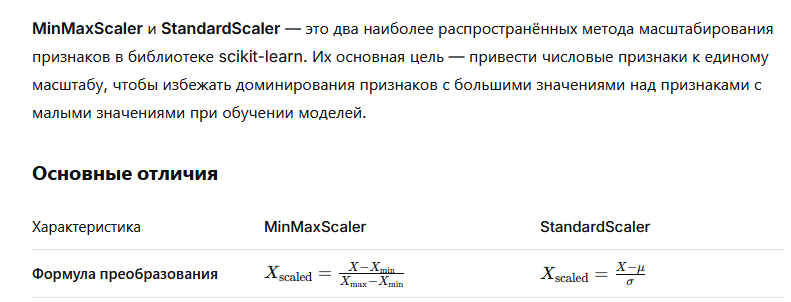

In [210]:
# Отмасштабируем таблицу X, так как линейные модели чувствительны к масштабу
from sklearn.preprocessing import MinMaxScaler

mm = MinMaxScaler()
mm.fit(Xtrain)
Xtrain = mm.transform(Xtrain)
Xtest = mm.transform(Xtest)

In [211]:
# Обучим Логистическую Регрессию и сравним accuracy на train и test

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score 

lr = LogisticRegression()
lr.fit(Xtrain, ytrain)

predLR = lr.predict(Xtest)
predLR_train = lr.predict(Xtrain)

accuracy_train = accuracy_score(ytrain, predLR_train)
accuracy_test = accuracy_score(ytest, predLR)

print(f'accuracy in train: {accuracy_train}, accuracy in test: {accuracy_test}')

accuracy in train: 0.6342857142857142, accuracy in test: 0.5766666666666667


In [212]:
#Попробуем добавить новых признаков в модель, используя PolynomialFeatures. Создайте полиномиальные признаки degree = 2.

from sklearn.preprocessing import PolynomialFeatures

pf = PolynomialFeatures(degree = 2)

pf.fit(Xtrain)

Xtrain_new = pf.transform(Xtrain)
Xtest_new = pf.transform(Xtest)

In [213]:
# На сколько признаков стало больше при добавлении полиномиальных признаков второй степени?

Xtrain_new.shape[1] - Xtrain.shape[1]

29

In [214]:
# Обучим Логистическую Регрессию и сравним accuracy на train и test после добавления полиномиальных признаков 2 степени

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score 

lr = LogisticRegression()
lr.fit(Xtrain_new, ytrain)

predLR_2 = lr.predict(Xtest_new)
predLR_train_2 = lr.predict(Xtrain_new)

accuracy_train_2 = accuracy_score(ytrain, predLR_train_2)
accuracy_test_2 = accuracy_score(ytest, predLR_2)

print(f'accuracy in train: {accuracy_train_2}, accuracy in test: {accuracy_test_2}')

accuracy in train: 0.6857142857142857, accuracy in test: 0.6233333333333333


In [215]:
# На сколько повысилось качество модели на тестовых данных? Ответ округлите до сотых.

round(accuracy_test_2 - accuracy_test, 2)

0.05

In [216]:
# Сначала посмотрите, какие значения recall и accuracy имеют предсказния модели на тесте с классами, предсказанными по умолчанию (методом predict).

from sklearn.metrics import recall_score

recall_test_2 = recall_score(ytest, predLR_2)

print(f'recall in test: {recall_test_2}, accuracy in test: {accuracy_test_2}')

recall in test: 0.6959459459459459, accuracy in test: 0.6233333333333333


In [217]:
# Разобъем тренировочные данные на трейн и валидацию, чтобы по валидационной части подбирать порог.

from sklearn.model_selection import train_test_split

XtrainS, Xval, ytrainS, yval = train_test_split(Xtrain, ytrain, test_size=0.3, random_state=42)

XtrainS.shape, Xval.shape

((490, 7), (210, 7))

In [222]:
# Обучите модель на тренировочных данных

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score 

lr = LogisticRegression()
lr.fit(XtrainS, ytrainS)

# Предскажите вероятности положительного класса на валидационных данных

proba_val = lr.predict_proba(Xval)[:, 1]

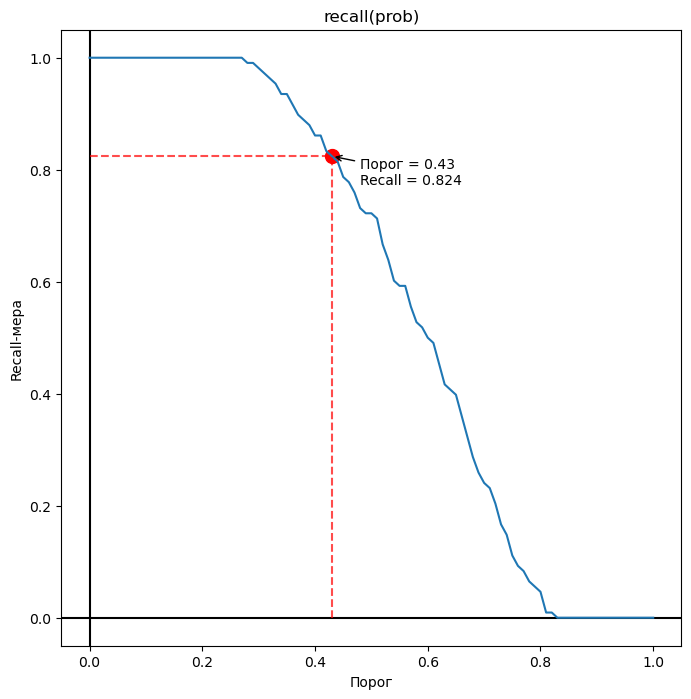

Порог, максимизирующий recall: 0.43
Значение recall при этом пороге: 0.8241
Значение accuracy для этого порога: 0.6000


In [229]:
# В цикле для каждого значения порога:

#    переведите вероятности в классы
#    вычислите полноту (на валидационных данных)
#Выведите на экран:

#    значение порога, дающее максимальный recall, при условии, что accuracy ≥ 0.6.

#    значение recall при этом пороге

#    значение accuracy для этого порога

#Ищите порог на отрезке от 0 до 1 с шагом 0.01.

from sklearn.metrics import accuracy_score, recall_score
import numpy as np
import matplotlib.pyplot as plt

# Предполагается, что proba_val и yval уже определены

prob_list = np.arange(0, 1.01, 0.01)
recall_list = []
acc_list = []  # не обязательно, но можно сохранять

best_recall = 0.0
best_threshold = None
best_accuracy = 0.0

for thr in prob_list:
    y_pred = (proba_val >= thr).astype(int)
    acc = accuracy_score(yval, y_pred)
    rec = recall_score(yval, y_pred)
    
    recall_list.append(rec)
    acc_list.append(acc)
    
    if acc >= 0.6 and rec > best_recall:
        best_recall = rec
        best_threshold = thr
        best_accuracy = acc

# Построение графика
plt.figure(figsize=(8, 8))

plt.axvline(x=0, c='black')
plt.axhline(y=0, c='black')
plt.title('recall(prob)')
plt.plot(prob_list, recall_list)

if best_threshold is not None:
    plt.scatter(best_threshold, best_recall, color='red', s=100, label='Максимум recall при accuracy≥0.6')
    plt.annotate(f'Порог = {best_threshold:.2f}\nRecall = {best_recall:.3f}', 
                 xy=(best_threshold, best_recall), 
                 xytext=(best_threshold+0.05, best_recall-0.05),
                 arrowprops=dict(arrowstyle='->'))
    plt.hlines(y=best_recall, xmin=min(prob_list), xmax=best_threshold, linestyle='--', color='red', alpha=0.7)
    plt.vlines(x=best_threshold, ymin=min(recall_list), ymax=best_recall, linestyle='--', color='red', alpha=0.7)

plt.xlabel('Порог')
plt.ylabel('Recall-мера')
plt.show()

# Вывод результатов
if best_threshold is not None:
    print(f'Порог, максимизирующий recall: {best_threshold:.2f}')
    print(f'Значение recall при этом пороге: {best_recall:.4f}')
    print(f'Значение accuracy для этого порога: {best_accuracy:.4f}')
else:
    print('Не найдено порогов с accuracy >= 0.6')

In [232]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, train_size = 0.7, random_state = 42)

lr_best = LogisticRegression()
lr_best.fit(Xtrain, ytrain)

predLR_best = lr_best.predict(Xtest)
probs_test = lr_best.predict_proba(Xtest)

predLR_best_threshold = (probs_test[:, 1] >= best_threshold).astype(int)

recall = recall_score(ytest, predLR_best_threshold)
recall

0.7905405405405406